In [1]:
%load_ext autoreload
%autoreload 2
%load_ext autotime

time: 184 µs (started: 2025-05-27 20:44:17 +08:00)


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
import matplotlib.gridspec as gridspec
from matplotlib.colors import Normalize, LogNorm
from matplotlib.colorbar import ColorbarBase
import matplotlib.ticker as ticker
import matplotlib.patches as patches

time: 518 ms (started: 2025-05-27 20:44:18 +08:00)


In [3]:
with open('fig5_data.pkl', 'rb') as f:
    fig5_data = pickle.load(f)
TD_reference = fig5_data['panel1_data']['TD_reference']
TD_potential = fig5_data['panel1_data']['TD_potential']
TD_generated = fig5_data['panel1_data']['TD_generated']
TD_retrained = fig5_data['panel1_data']['TD_retrained']
TD_L_list  = fig5_data['panel2_data']['TD_L_list']
TD_sJ_list = fig5_data['panel2_data']['TD_sJ_list']
TD_fi_list = fig5_data['panel2_data']['TD_fi_list']

time: 984 ms (started: 2025-05-27 20:44:18 +08:00)


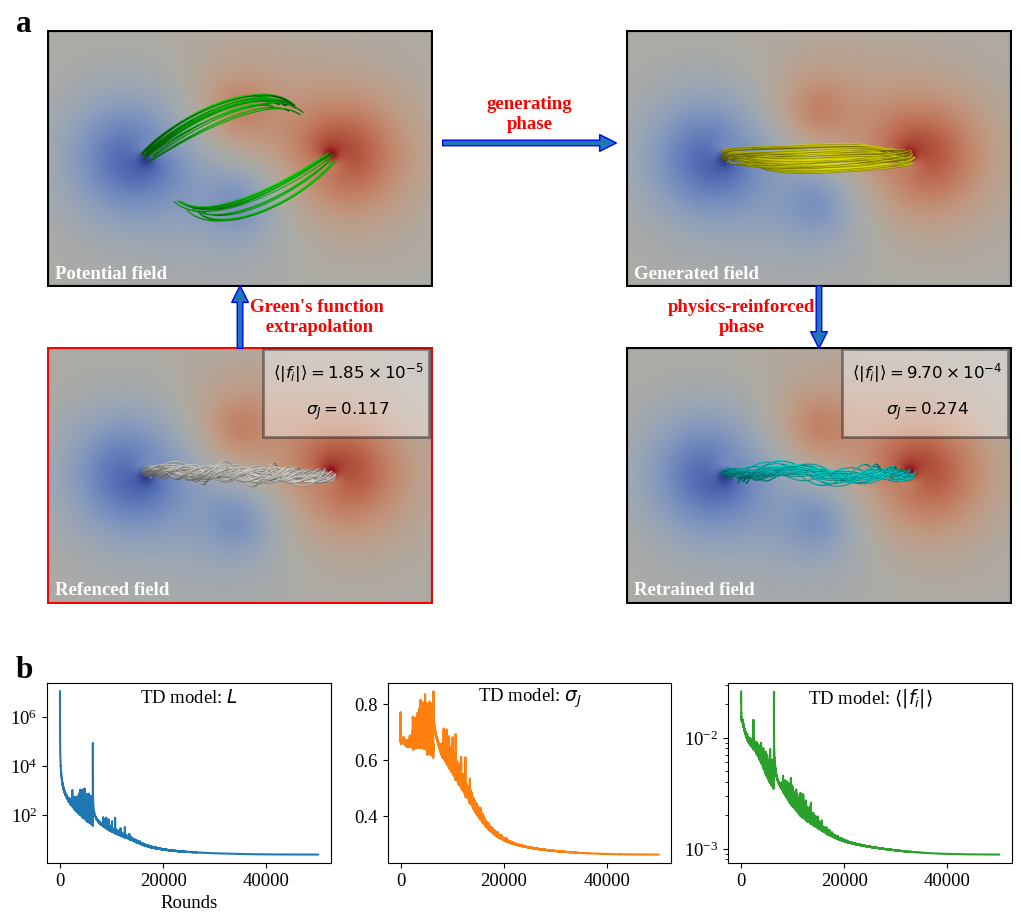

time: 7.87 s (started: 2025-05-27 20:45:55 +08:00)


In [8]:
zoom_factor = 1.5
plt.rcParams['font.size'] = 9.0*zoom_factor
plt.rcParams['font.family']='Liberation Serif'
A4_width = 8.3*zoom_factor
A4_length = 11.7*zoom_factor
golden_ratio = 0.618

def get_axes_vertices(ax):
    vertices = [(0, 0), (1, 0), (1, 1), (0, 1)]
    transformed_vertices = [ax.transAxes.transform(v) for v in vertices]
    transformed_vertices = [fig.transFigure.inverted().transform(v) for v in transformed_vertices]
    return transformed_vertices

img_ratio_td = TD_reference.shape[0]/TD_reference.shape[1]
height, width = TD_reference.shape[:2]
# plotting
plot_height = A4_width*(img_ratio_td+golden_ratio/3)
hspace_inches = plot_height*0.15
total_height = plot_height+hspace_inches*3
hspace_value = hspace_inches/total_height
fig = plt.figure(figsize=(A4_width, plot_height))
gs = gridspec.GridSpec(2, 1, height_ratios=[img_ratio_td,golden_ratio/3], hspace=0.2)

### panel 3 ###
gs3 = gridspec.GridSpecFromSubplotSpec(2, 2, subplot_spec=gs[0], wspace=0.50, hspace=0.20)
ax = fig.add_subplot(gs3[1,0])
plt.imshow(TD_reference, aspect='equal')
plt.axis('off')
border_width  = 3
border_color  = 'red'
rect = patches.Rectangle((0,0), width, height, linewidth=border_width, edgecolor=border_color, facecolor='none')
plt.gca().add_patch(rect)
plt.text(0.02,0.02,'Refenced field',transform=plt.gca().transAxes,ha='left',va='bottom',fontsize=9.0*zoom_factor, color='white',fontweight='bold')
vertices3 = get_axes_vertices(plt.gca())
rect = patches.Rectangle((0.56,0.65), 0.43,0.34, linewidth=2, edgecolor='black', facecolor='white',alpha=0.4,transform=plt.gca().transAxes)
plt.gca().add_patch(rect)
plt.text(0.78,0.90,r'$\langle |f_i|\rangle=1.85\times 10^{-5}$',
         transform=plt.gca().transAxes,ha='center',va='center',fontsize=8.0*zoom_factor,color='black',
         fontdict={'family':'Times New Roman'})
plt.text(0.78,0.75,'$\sigma_J=0.117$',
         transform=plt.gca().transAxes,ha='center',va='center',fontsize=8.0*zoom_factor,color='black',fontweight='bold',
         fontdict={'family':'Times New Roman'})

ax = fig.add_subplot(gs3[0,0]) # plt.subplot(221)
plt.imshow(TD_potential, aspect='equal')
plt.axis('off')
border_color  = 'black'
rect = patches.Rectangle((0,0), width, height, linewidth=border_width, edgecolor=border_color, facecolor='none')
plt.gca().add_patch(rect)
plt.text(0.02,0.02,'Potential field',transform=plt.gca().transAxes,ha='left',va='bottom',fontsize=9.0*zoom_factor, color='white',fontweight='bold')
vertices1 = get_axes_vertices(plt.gca())

ax = fig.add_subplot(gs3[0,1]) # plt.subplot(222)
plt.imshow(TD_generated, aspect='equal')
plt.axis('off')
border_color  = 'black'
rect = patches.Rectangle((0,0), width, height, linewidth=border_width, edgecolor=border_color, facecolor='none')
plt.gca().add_patch(rect)
plt.text(0.02,0.02,'Generated field',transform=plt.gca().transAxes,ha='left',va='bottom',fontsize=9.0*zoom_factor, color='white',fontweight='bold')
vertices2 = get_axes_vertices(plt.gca())

ax=fig.add_subplot(gs3[1,1]) # plt.subplot(224)
plt.imshow(TD_retrained, aspect='equal')
plt.axis('off')
border_color  = 'black'
rect = patches.Rectangle((0,0), width, height, linewidth=border_width, edgecolor=border_color, facecolor='none')
plt.gca().add_patch(rect)
plt.text(0.02,0.02,'Retrained field',transform=plt.gca().transAxes,ha='left',va='bottom',fontsize=9.0*zoom_factor, color='white',fontweight='bold')
vertices4 = get_axes_vertices(plt.gca())
rect = patches.Rectangle((0.56,0.65), 0.43,0.34, linewidth=2, edgecolor='black', facecolor='white',alpha=0.4,transform=plt.gca().transAxes)
plt.gca().add_patch(rect)
plt.text(0.78,0.90,r'$\langle |f_i|\rangle=9.70\times 10^{-4}$',
         transform=plt.gca().transAxes,ha='center',va='center',fontsize=8.0*zoom_factor,color='black',
         fontdict={'family':'Times New Roman'})
plt.text(0.78,0.75,'$\sigma_J=0.274$',
         transform=plt.gca().transAxes,ha='center',va='center',fontsize=8.0*zoom_factor,color='black',fontweight='bold',
         fontdict={'family':'Times New Roman'})

ax = fig.add_subplot(gs[0]) # plt.subplot(111)
arrow_start = (0.2, 0.44)
arrow_end   = (0.2, 0.56)
plt.annotate('', xy=arrow_end, xycoords='axes fraction', xytext=arrow_start, textcoords='axes fraction', 
             arrowprops=dict(facecolor='C0', edgecolor='blue', linewidth=1, shrink=0.05))
arrow_start = (0.8, 0.56)
arrow_end   = (0.8, 0.44)
plt.annotate('', xy=arrow_end, xycoords='axes fraction', xytext=arrow_start, textcoords='axes fraction', 
             arrowprops=dict(facecolor='C0', edgecolor='blue', linewidth=1, shrink=0.05))
arrow_start = (0.4, 0.8)
arrow_end   = (0.6, 0.8)
plt.annotate('', xy=arrow_end, xycoords='axes fraction', xytext=arrow_start, textcoords='axes fraction', 
             arrowprops=dict(facecolor='C0', edgecolor='blue', linewidth=1, shrink=0.05))
plt.axis('off')

plt.text(0.28, 0.50, "Green's function\n extrapolation", 
         fontsize=9*zoom_factor, fontweight='bold', ha='center', va='center', color='red')
plt.text(0.50, 0.85, "generating\nphase", 
         fontsize=9*zoom_factor, fontweight='bold', ha='center', va='center', color='red')
# plt.text(0.72, 0.50, "PIG\nmodel", 
#          fontsize=9*zoom_factor, fontweight='bold', ha='center', va='center', color='red')
plt.text(0.72, 0.50, "physics-reinforced\nphase", 
         fontsize=9*zoom_factor, fontweight='bold', ha='center', va='center', color='red')

### panel 4 ###
gs4= gridspec.GridSpecFromSubplotSpec(1, 3, subplot_spec=gs[1], wspace=0.2, hspace=0.00)
ax = fig.add_subplot(gs4[0])
plt.plot(TD_L_list, label='L', c='C0')
plt.yscale('log')
plt.text(0.5,0.92,'TD model: $L$', transform=plt.gca().transAxes,ha='center',va='center')
plt.xlabel('Rounds')

ax = fig.add_subplot(gs4[1])
plt.plot(TD_sJ_list, label='$\sigma_J$', c='C1')
plt.text(0.5,0.92,'TD model: $\sigma_J$', transform=plt.gca().transAxes,ha='center',va='center')

ax = fig.add_subplot(gs4[2])
plt.plot(TD_fi_list, label=r'$\left<\|f_i\|\right>$', c='C2')
plt.yscale('log')
plt.text(0.5,0.92,r'TD model: $\langle |f_i| \rangle$', transform=plt.gca().transAxes,ha='center',va='center')

xx = 0.10
ya = 0.896
yb = 0.301
fig.text(xx, ya, 'a', fontsize=15*zoom_factor, fontweight='bold', ha='left', va='top')
fig.text(xx, yb, 'b', fontsize=15*zoom_factor, fontweight='bold', ha='left', va='top')

plt.subplots_adjust(hspace=0.00)
plt.savefig('fig5.pdf', bbox_inches='tight', dpi=400)
plt.savefig('fig5.png', bbox_inches='tight', dpi=400)
plt.show()